# ICH Texture Analysis and Generation

See [Issue 143 on characterizing ICH texture](https://github.com/DIDSR/InSilicoICH/issues/143)

## Characterize ICH Texture in Real-World Data

Datasets:
1. Hssayeni: `/gpfs_projects/common_data/CT_intracranial_hemorrhage`
2. INSTANCE: `/gpfs_projects/jayse.weaver/INSTANCE2022_Dataset`
3. BHSD: `/gpfs_projects/brandon.nelson/datasets/BHSD`
4. CQ500? 

In [1]:
from dotenv import load_dotenv
from pathlib import Path
import os
import pandas as pd
load_dotenv()

ct_ich_dataset_path = Path(os.environ.get('HSSAYENI_DIRECTORY'))
patients = pd.read_csv(ct_ich_dataset_path / 'Patient_demographics.csv', index_col=0)
lesions = pd.read_csv(ct_ich_dataset_path / 'hemorrhage_diagnosis_raw_ct.csv')
lesions

,PatientNumber,SliceNumber,Intraventricular,Intraparenchymal,Subarachnoid,Epidural,Subdural,No_Hemorrhage,Fracture_Yes_No
0,49,1,0,0,0,0,0,1,0
1,49,2,0,0,0,0,0,1,0
2,49,3,0,0,0,0,0,1,0
3,49,4,0,0,0,0,0,1,0
4,49,5,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...
2809,130,32,0,0,0,0,0,1,0
2810,130,33,0,0,0,0,0,1,0
2811,130,34,0,0,0,0,0,1,0
2812,130,35,0,0,0,0,0,1,0


Use [Pyradiomics](https://github.com/AIM-Harvard/pyradiomics) to get first order, shape, and texture features:

The goal is to measure these features on the real datasets and synthetic then iterate the synthetic data parameters to get the radiomics features to match (can do this manually or iteratively)

In [2]:
import numpy as np

--- Global Maximum Intensity Projections ---


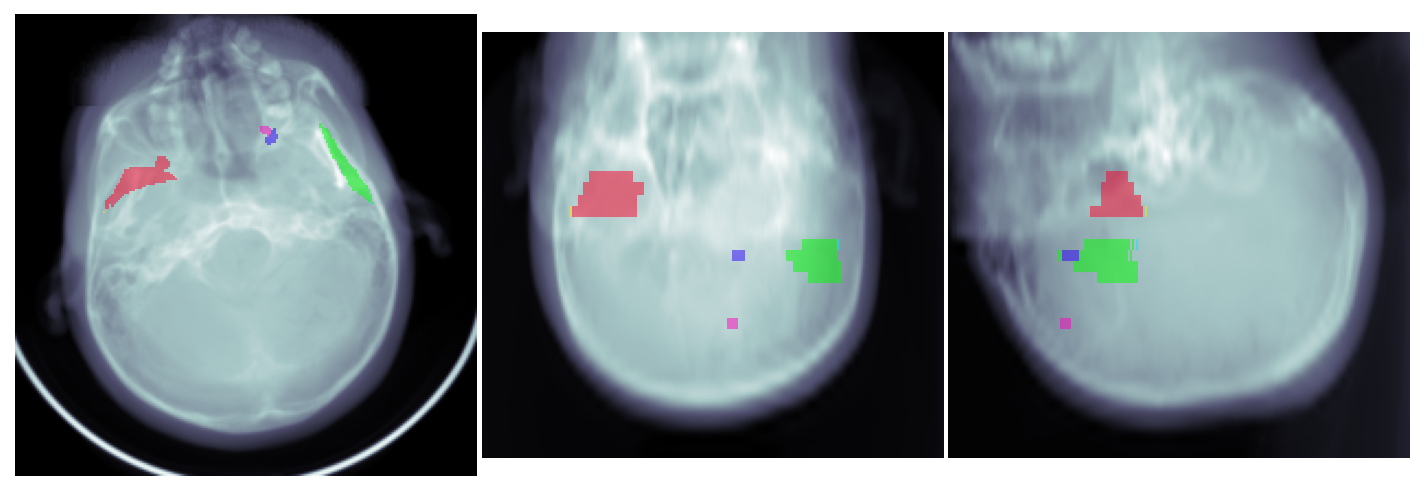


--- Individual Hemorrhage Cross-Sectional Views ---


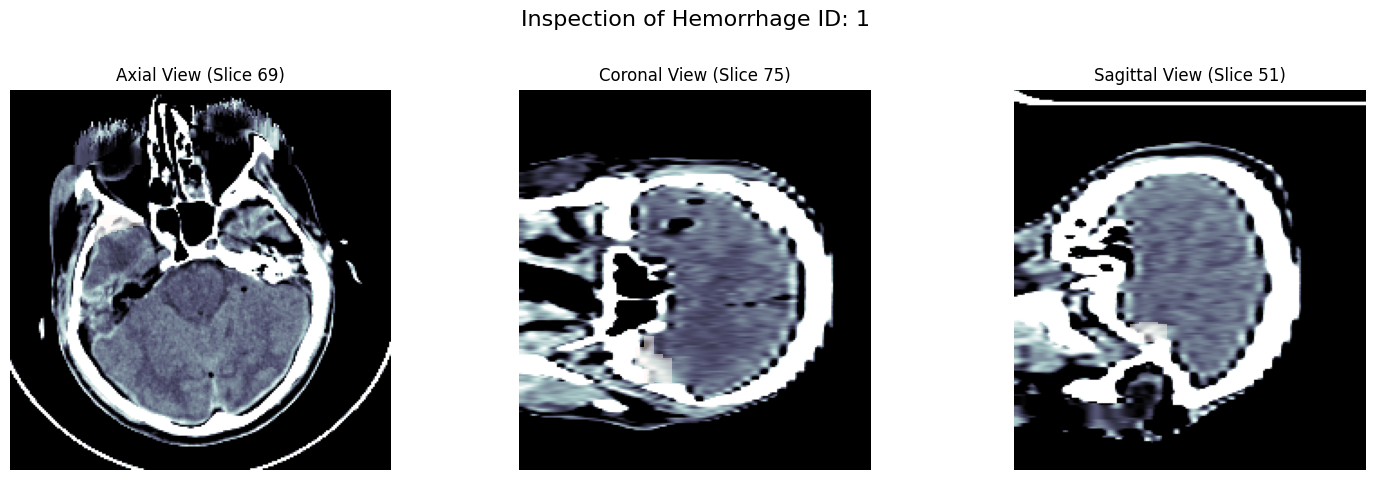

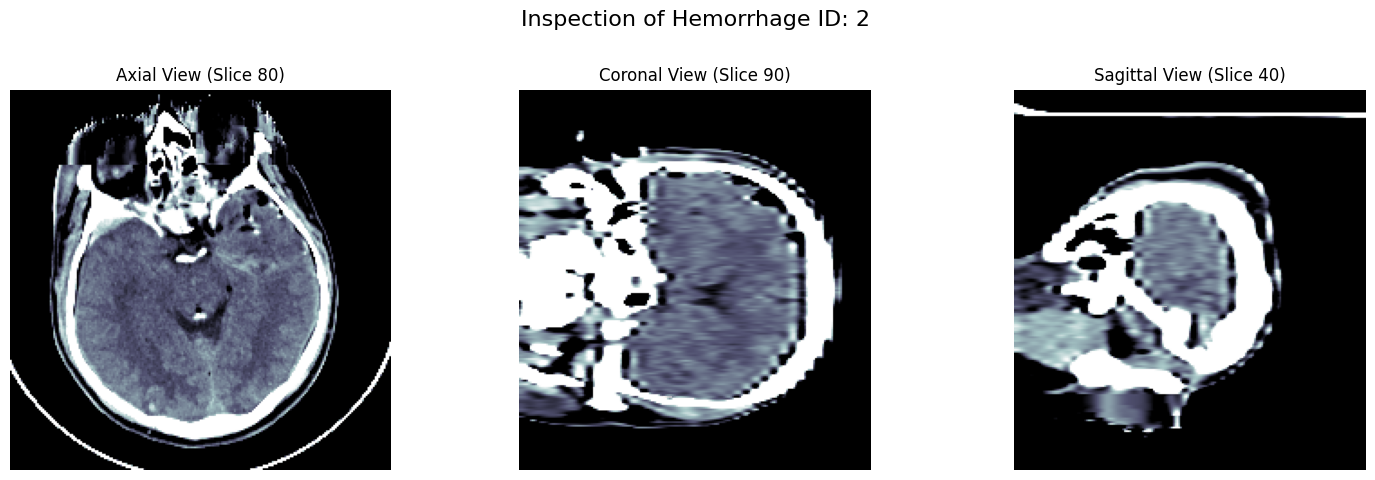

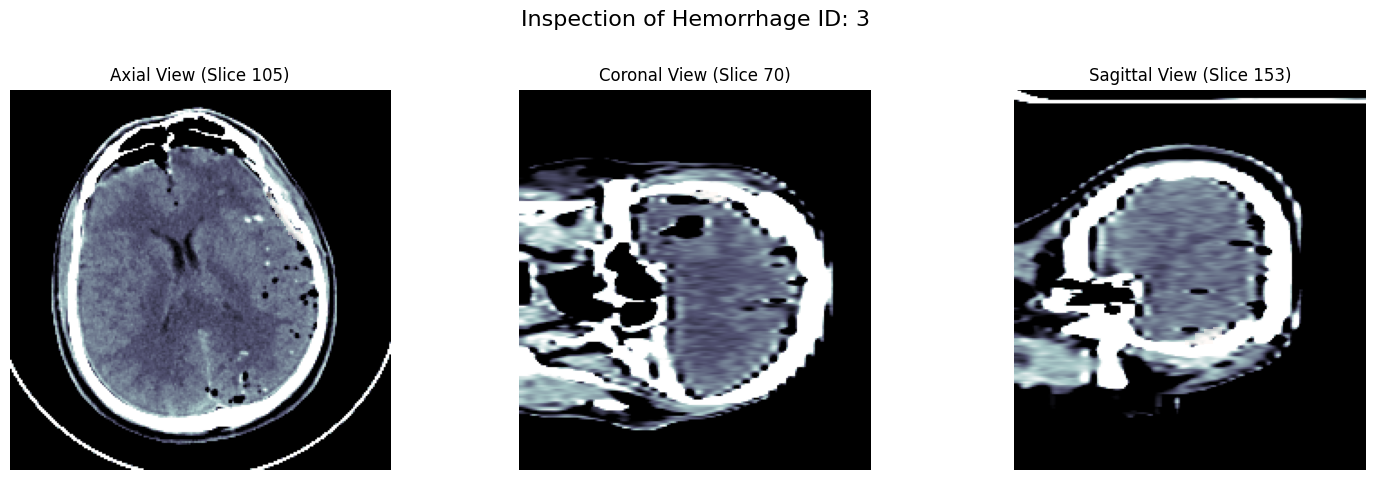

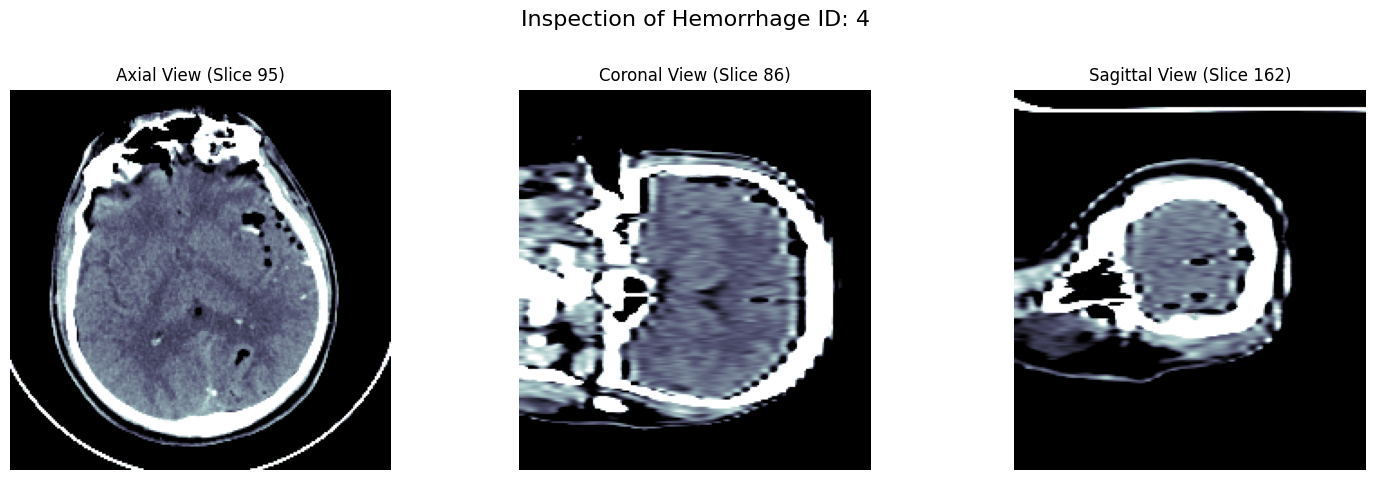

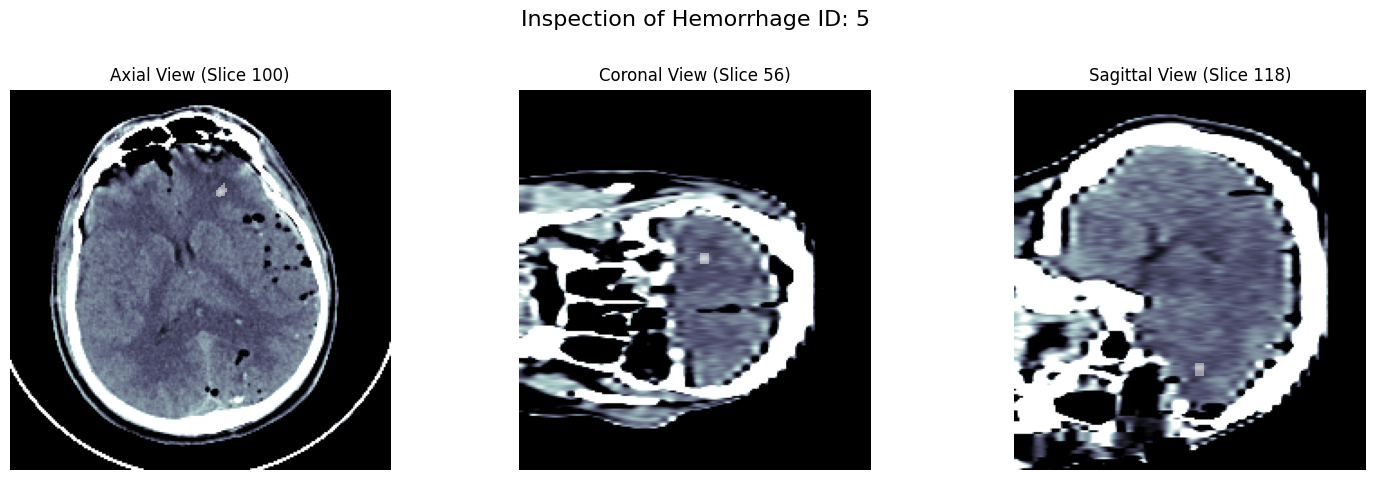

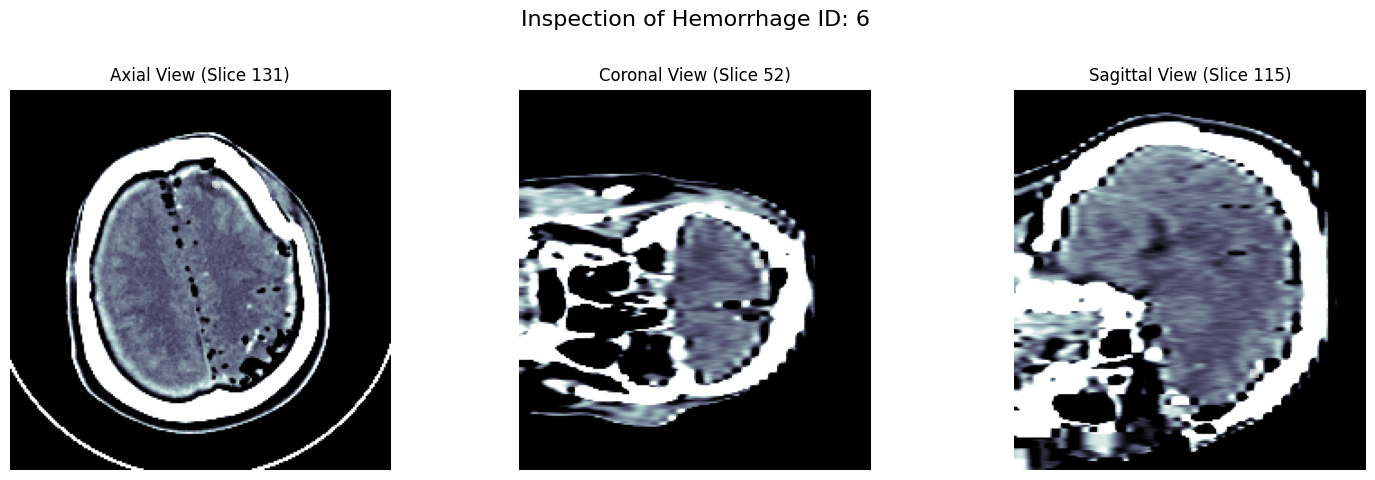

In [3]:
import matplotlib.pyplot as plt
from skimage.measure import label
from data import load_hssayeni_image_mask_pair, visualize_ich_projections, visualize_ich_slices

target_spacing = (1, 1, 1) 
img, mask = load_hssayeni_image_mask_pair(ct_ich_dataset_path, 49, target_spacing)
mask = label(mask)

visualize_ich_projections(img, mask)
visualize_ich_slices(img, mask)

Make a for loop that makes a montage showing the alpha overlay of every segmentation and reports the important GLCM metrics then collect those metrics and plot them for all patients. Then compare and summarize these by volume, subtype and other metadata

(This characterization will be an important part of the paper)

In [4]:
from measures import calculate_glcm_metrics_3d, calculate_sphericity

lesion_mask = np.zeros_like(mask)
lesion_mask[mask==1] = True

distance = [3, 5, 7]
glcm_metrics = calculate_glcm_metrics_3d(img, lesion_mask, distances=distance, levels=32)
glcm_metrics['sphericity'] = calculate_sphericity(lesion_mask)
glcm_metrics

{'contrast': np.float64(16.328917061374938),
 'correlation': np.float64(0.17888710748575576),
 'energy': np.float64(0.4597147110149856),
 'homogeneity': np.float64(0.5368895946668436),
 'dissimilarity': np.float64(2.591398556590162),
 'sphericity': np.float64(0.5569815536115967)}

Consider adding sphericity and flatness as additional shape features in addition to volume and textures

In [34]:
from tqdm import tqdm
import numpy as np

contrast = []
correlation = []
distances = []
patient_numbers = []
images = []
masks = []
volumes = []
attenuation = []
sphericity = []
subtypes = []

target_spacing = (1, 1, 1)
available_lesions = ['Intraparenchymal', 'Epidural', 'Subdural', 'Intraventricular', 'Subarachnoid']

for id in tqdm(patients.index[~patients.index.isna()].astype(int)):
    volume, mask, resample_factor = load_hssayeni_image_mask_pair(ct_ich_dataset_path, id, target_spacing=target_spacing, return_resample_factor=True)
    if volume is None:
        continue
    if mask.sum() == 0:
        continue
    mask = label(mask)
    lesion_values = np.unique(mask)[1:]
    for lesion_value in lesion_values:
        lesion_mask = np.zeros_like(mask).astype(bool)
        lesion_mask[(mask == lesion_value) & (volume > 0) & (volume <= 200)] = True # includes resegmentation described by https://www.frontiersin.org/journals/neuroscience/articles/10.3389/fnins.2023.1225342/full#supplementary-material
        volume_voxel = lesion_mask.sum()
        volume_mL = volume_voxel*target_spacing[0]**3/1000
        volumes.append(volume_mL)
        attenuation.append(volume[lesion_mask].mean())

        glcm_metrics = calculate_glcm_metrics_3d(volume, lesion_mask, distances=[3, 5, 7], levels=32)
        contrast.append(glcm_metrics['contrast'])
        correlation.append(glcm_metrics['correlation'])
        patient_numbers.append(id)
        z = int(lesion_mask.sum(axis=(1, 2)).argmax() / resample_factor[2])
        row = lesions[(lesions['PatientNumber'] == id) & (lesions['SliceNumber'] == z)]
        lesion = ''
        for candidate in available_lesions:
            if row[candidate].item():
                lesion = lesion + candidate + ' '
        subtypes.append(lesion)

        images.append(volume[z])
        masks.append(mask[z])
        sphericity.append(calculate_sphericity(lesion_mask))

hssayeni = pd.DataFrame({'ID': patient_numbers, 'subtype': subtypes, 'volume': volumes, 'attenuation': attenuation, 'glcm contrast': contrast, 'glcm correlation': correlation, 'sphericity': sphericity})
hssayeni['dataset'] = 'hssayeni'
hssayeni

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 82/82 [02:55<00:00,  2.15s/it]


,ID,subtype,volume,attenuation,glcm contrast,glcm correlation,sphericity,dataset
0,49,Epidural,3.260,58.565401,41.819357,0.148952,0.536173,hssayeni
1,49,Epidural,0.005,61.556362,0.000000,1.000000,1.083914,hssayeni
2,49,Intraparenchymal Epidural,1.685,72.079094,36.131919,0.055714,0.412322,hssayeni
3,49,,0.005,39.693627,0.000000,1.000000,1.083914,hssayeni
4,49,Epidural,0.145,36.083794,105.022269,-0.046464,0.858514,hssayeni
...,...,...,...,...,...,...,...,...
73,94,Intraventricular,1.770,35.754962,86.659022,0.058193,0.578586,hssayeni
74,94,Intraparenchymal Intraventricular,4.040,46.969415,134.674524,0.050263,0.467537,hssayeni
75,94,Intraparenchymal Intraventricular,52.773,48.494494,13.780743,0.540849,0.425418,hssayeni
76,94,Intraparenchymal Intraventricular,1.714,48.111029,111.169988,0.231887,0.623005,hssayeni


In [35]:
hssayeni.replace('Intraparenchymal Intraventricular	', 'Intraparenchymal ', inplace=True)
hssayeni.replace('Intraparenchymal Epidural	', 'Intraparenchymal ', inplace=True)
hssayeni

,ID,subtype,volume,attenuation,glcm contrast,glcm correlation,sphericity,dataset
0,49,Epidural,3.260,58.565401,41.819357,0.148952,0.536173,hssayeni
1,49,Epidural,0.005,61.556362,0.000000,1.000000,1.083914,hssayeni
2,49,Intraparenchymal Epidural,1.685,72.079094,36.131919,0.055714,0.412322,hssayeni
3,49,,0.005,39.693627,0.000000,1.000000,1.083914,hssayeni
4,49,Epidural,0.145,36.083794,105.022269,-0.046464,0.858514,hssayeni
...,...,...,...,...,...,...,...,...
73,94,Intraventricular,1.770,35.754962,86.659022,0.058193,0.578586,hssayeni
74,94,Intraparenchymal Intraventricular,4.040,46.969415,134.674524,0.050263,0.467537,hssayeni
75,94,Intraparenchymal Intraventricular,52.773,48.494494,13.780743,0.540849,0.425418,hssayeni
76,94,Intraparenchymal Intraventricular,1.714,48.111029,111.169988,0.231887,0.623005,hssayeni


In [36]:
hssayeni['ID'] = pd.Categorical(hssayeni['ID'])
hssayeni['subtype'] = pd.Categorical(hssayeni['subtype'])
hssayeni

,ID,subtype,volume,attenuation,glcm contrast,glcm correlation,sphericity,dataset
0,49,Epidural,3.260,58.565401,41.819357,0.148952,0.536173,hssayeni
1,49,Epidural,0.005,61.556362,0.000000,1.000000,1.083914,hssayeni
2,49,Intraparenchymal Epidural,1.685,72.079094,36.131919,0.055714,0.412322,hssayeni
3,49,,0.005,39.693627,0.000000,1.000000,1.083914,hssayeni
4,49,Epidural,0.145,36.083794,105.022269,-0.046464,0.858514,hssayeni
...,...,...,...,...,...,...,...,...
73,94,Intraventricular,1.770,35.754962,86.659022,0.058193,0.578586,hssayeni
74,94,Intraparenchymal Intraventricular,4.040,46.969415,134.674524,0.050263,0.467537,hssayeni
75,94,Intraparenchymal Intraventricular,52.773,48.494494,13.780743,0.540849,0.425418,hssayeni
76,94,Intraparenchymal Intraventricular,1.714,48.111029,111.169988,0.231887,0.623005,hssayeni


In [37]:
hssayeni.corr(numeric_only=True)

,volume,attenuation,glcm contrast,glcm correlation,sphericity
volume,1.000000,0.189875,-0.261238,0.346860,-0.385450
attenuation,0.189875,1.000000,-0.243587,0.068128,-0.262171
glcm contrast,-0.261238,-0.243587,1.000000,-0.484643,0.428363
glcm correlation,0.346860,0.068128,-0.484643,1.000000,0.011742
sphericity,-0.385450,-0.262171,0.428363,0.011742,1.000000


In [38]:
hssayeni.describe()

,volume,attenuation,glcm contrast,glcm correlation,sphericity
count,78.000000,78.000000,78.000000,78.000000,78.000000
mean,6.845321,50.230563,71.134739,0.108940,0.584396
std,16.999329,10.569437,57.130678,0.216797,0.184798
min,0.005000,22.199776,0.000000,-0.179385,0.238989
25%,0.528000,42.967020,28.561090,-0.032727,0.427138
50%,1.664500,49.501256,50.760126,0.089383,0.588883
75%,4.601000,57.587663,105.276298,0.190740,0.718525
max,114.044000,72.079094,280.758722,1.000000,1.083914


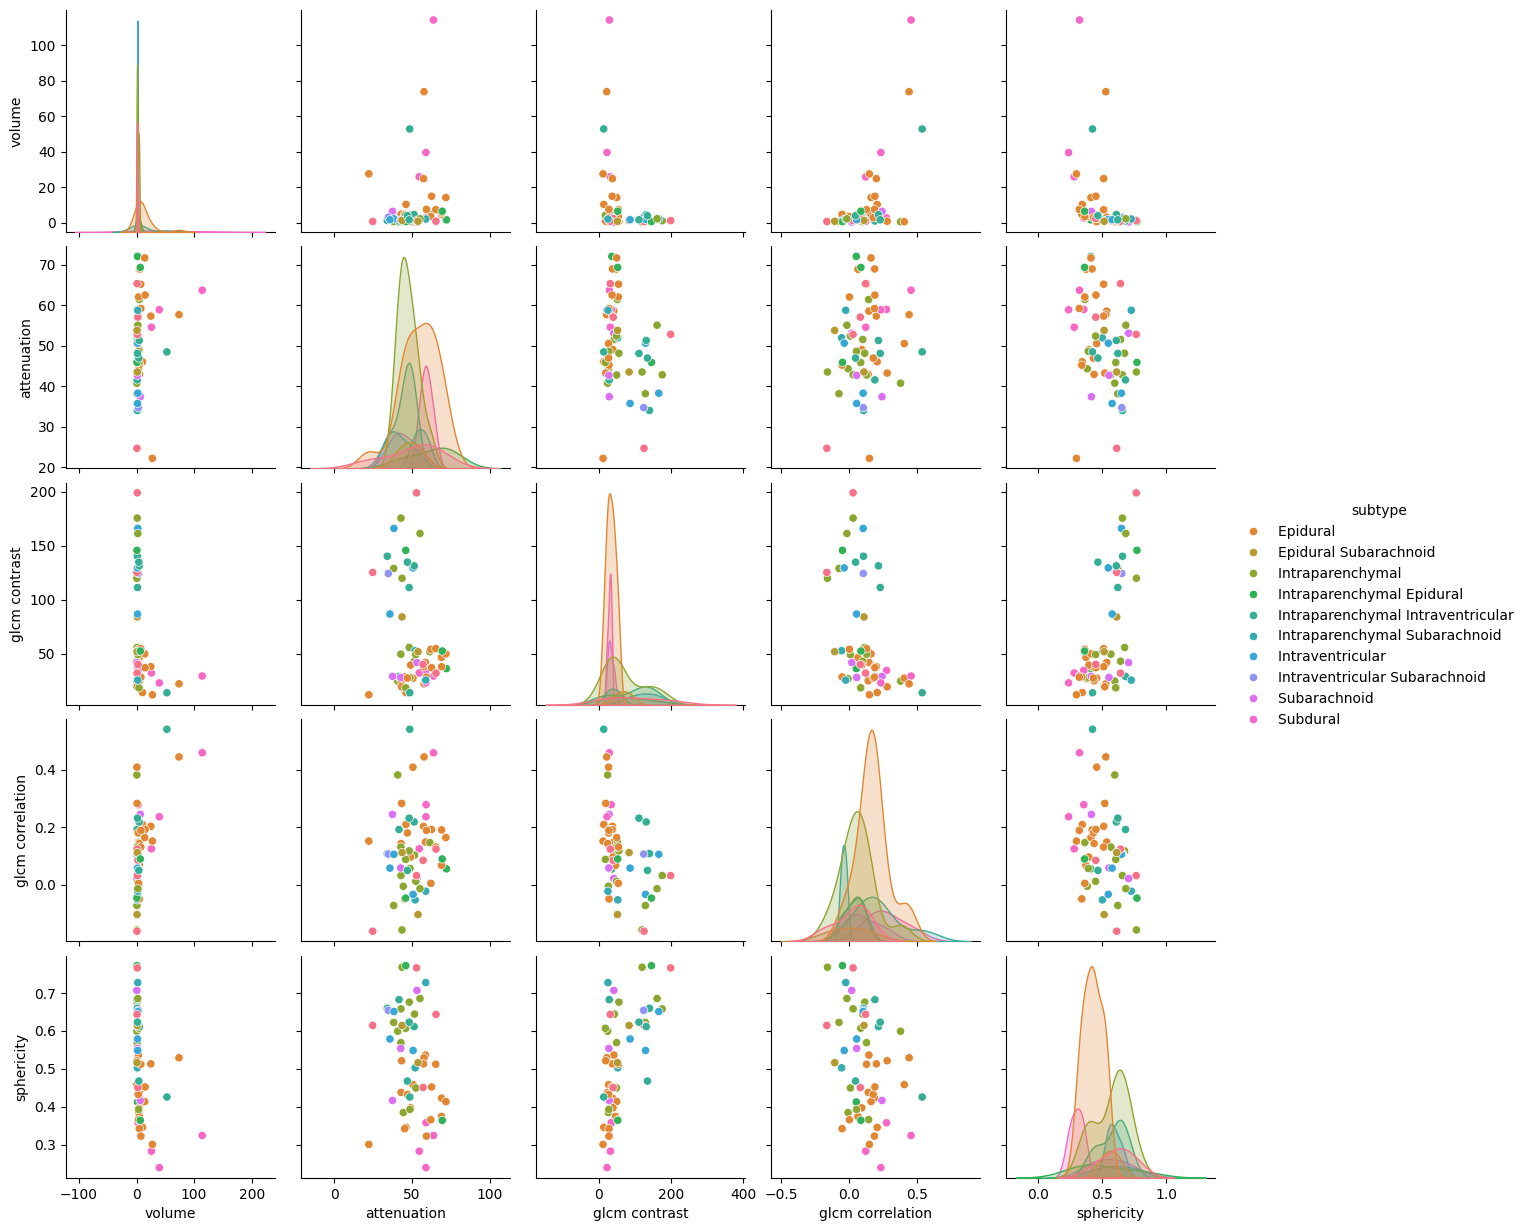

In [39]:
import seaborn as sns
sns.pairplot(data=hssayeni[hssayeni['volume']>0.5], hue='subtype')

In [ ]:
sns.scatterplot(data=df, x='correlation', y='contrast', hue='subtype')

In [ ]:
import matplotlib.pyplot as plt
import math
from skimage.measure import regionprops, label
from matplotlib import patches

from utils import generate_distinct_colors, ctshow

def create_image_montage(images, masks, dataframe, display='brain'):
    """
    Creates and displays a square montage of images.

    Args:
        images (list): A list of 2D NumPy ndarrays representing the images.
        masks (list): A list of 2D NumPy ndarrays representing the masks.
    """
    num_images = len(images)
    colors = generate_distinct_colors(len(masks), 'tab10')

    grid_size = math.ceil(math.sqrt(num_images))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(20, 20), gridspec_kw=dict(hspace=0, wspace=0), dpi=300)
    axes = axes.flatten()
    for i, (img, mask, c) in enumerate(zip(images, masks, colors)):
        ax = axes[i]
        row = dataframe.iloc[i]
        ctshow(img, display, fig=fig, ax=ax)
        reg = regionprops(label(mask))[0]
        rect = patches.Rectangle((reg.bbox[1], reg.bbox[0]), reg.bbox[3] - reg.bbox[1],
                                  reg.bbox[2] - reg.bbox[0], linewidth=1, edgecolor=c, facecolor='none')
        ax.add_patch(rect)
        ann = f"{int(row['ID']):d} {row['subtype']}\n{row['volume']:2.2f} mL con: {row['contrast']:2.2f}, cor: {row['correlation']:2.2f}"
        bbox = dict(boxstyle="round", fc="0.8")
        ax.annotate(ann, (10, 10), bbox=bbox, fontsize=4)
        ax.axis('off') # Hide the axes

In [ ]:
create_image_montage(images, masks, df)

## Make Synthetic ICH

In [ ]:
import VITools
available_phantoms = VITools.get_available_phantoms()
available_phantoms

In [ ]:
phantom = available_phantoms['6.5 yr NIHPD Head']()
phantom

In [ ]:
import numpy as np

phantom = available_phantoms['6.5 yr NIHPD Head']()
scales = np.linspace(1, 20, 10, dtype=int)
seeds = np.arange(len(scales))
for scale, seed in zip(scales, seeds):
    phantom.insert_lesion('IPH', mass_effect=0, intensity=50, volume=2, complexity=3,
                        smoothness=0.2, irregularity=0.5, eccentricity=0.6, edema=2,
                        seed=seed, texture_kwargs=dict(noise_type='perlin', contrast_std=1, scale=scale))

In [ ]:
from utils import ctshow, generate_distinct_colors
from skimage.measure import label, regionprops
import matplotlib.patches as patches
import matplotlib.pyplot as plt


volume = phantom.get_CT_number_phantom()
colors = generate_distinct_colors(len(phantom.lesions), 'tab10')
f, axs = plt.subplots(1, len(phantom.lesions), gridspec_kw=dict(hspace=0, wspace=0), dpi=150, figsize=(10, 5))
for idx, (ax, c, scale) in enumerate(zip(axs, colors, scales)):
    mask = phantom.lesions[idx].mask
    ctshow(volume[phantom.lesions[idx].coords_voxel[0]], 'brain', fig=f, ax=ax)
    reg = regionprops(label(mask[phantom.lesions[idx].coords_voxel[0]]))[0]
    rect = patches.Rectangle((reg.bbox[1], reg.bbox[0]), reg.bbox[3] - reg.bbox[1],
                              reg.bbox[2] - reg.bbox[0], linewidth=1, edgecolor=c, facecolor='none')
    ax.add_patch(rect)
    ax.set_title(scale)

In [ ]:
scales = list(np.linspace(1, 20, 10, dtype=int))

In [ ]:
import pandas as pd
volume = phantom.get_CT_number_phantom()

contrast = []
correlation = []
distances = []
scales_list = []

for distance in [1, 3, 5, 7]:
    for scale, lesion in zip(scales, phantom.lesions):
        mask = lesion.mask
        glcm_metrics = calculate_glcm_metrics_3d(volume, mask, distances=[distance], levels=32)
        glcm_metrics['scale'] = scale
        scales_list.append(scale)
        distances.append(distance)
        contrast.append(glcm_metrics['contrast'])
        correlation.append(glcm_metrics['correlation'])
df = pd.DataFrame({'scale': scales_list, 'distances': distances, 'contrast': contrast, 'correlation': correlation})
df

In [ ]:
import seaborn as sns
sns.scatterplot(data=df, x='distances', y='contrast', hue='scale', palette='viridis')

In [ ]:
sns.scatterplot(data=df, x='distances', y='correlation', hue='scale', palette='viridis')

In [ ]:
sns.scatterplot(data=df, x='scale', y='contrast', hue='distances', palette='viridis')

In [ ]:
contrast = []
correlation = []
distances = []
scales_list = []

for scale, lesion in zip(scales, phantom.lesions):
    mask = lesion.mask
    glcm_metrics = calculate_glcm_metrics_3d(volume, mask, distances=[3, 5, 7], levels=32)
    glcm_metrics['scale'] = scale
    scales_list.append(scale)
    distances.append(distance)
    contrast.append(glcm_metrics['contrast'])
    correlation.append(glcm_metrics['correlation'])
df = pd.DataFrame({'scale': scales_list, 'contrast': contrast, 'correlation': correlation})
df

In [ ]:
sns.scatterplot(data=df, x='scale', y='contrast', palette='viridis')

In [ ]:
sns.scatterplot(data=df, x='scale', y='correlation', palette='viridis')

Correlation is the measured radiomic quantity, scale is the input parameter to the Perlin noise generator to make synthetic texture

Now add real data

In [ ]:
# colors = generate_distinct_colors(len(phantom.lesions), 'tab10')
f, axs = plt.subplots(1, len(phantom.lesions), gridspec_kw=dict(hspace=0, wspace=0), dpi=150, figsize=(10, 5))
for idx, (ax, c, scale) in enumerate(zip(axs, colors, scales)):
    mask = phantom.lesions[idx].mask
    ctshow(volume[phantom.lesions[idx].coords_voxel[0]], 'brain', fig=f, ax=ax)
    reg = regionprops(label(mask[phantom.lesions[idx].coords_voxel[0]]))[0]
    rect = patches.Rectangle((reg.bbox[1], reg.bbox[0]), reg.bbox[3] - reg.bbox[1],
                              reg.bbox[2] - reg.bbox[0], linewidth=1, edgecolor=c, facecolor='none')
    ax.add_patch(rect)
    ax.set_title(scale)